In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Resolve path to the statistical output directory
stats_dir = Path('../../output/analysis/statistical').resolve()
csv_file = stats_dir / "group_behavioral_metrics.csv"

if csv_file.exists():
    df = pd.read_csv(csv_file)
    print(f"Successfully loaded aggregated group data. Total sessions: {len(df)}")
    display(df.head()) # Shows the raw rows and columns
else:
    print(f"File not found: {csv_file}")

Successfully loaded aggregated group data. Total sessions: 6


,predictability,win_stay_rate,lose_shift_rate,cycling_rate,forward_cycling,backward_cycling,subject,player
0,0.019797,0.393750,0.558621,0.574113,0.294363,0.279749,sub-01,P1
1,0.008893,0.220690,0.806250,0.695198,0.340292,0.354906,sub-01,P2
2,0.033113,0.239130,0.803468,0.745303,0.390397,0.354906,sub-02,P1
3,0.136401,0.075145,0.755435,0.787056,0.215031,0.572025,sub-02,P2
4,0.033781,0.106509,0.621795,0.778706,0.359081,0.419624,sub-03,P1


C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_6732\2569555915.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='player', y='win_stay_rate', data=df, ax=ax1, width=0.4, palette='pastel')
C:\Users\Ayush Batra\AppData\Local\Temp\ipykernel_6732\2569555915.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='player', y='lose_shift_rate', data=df, ax=ax2, width=0.4, palette='pastel')


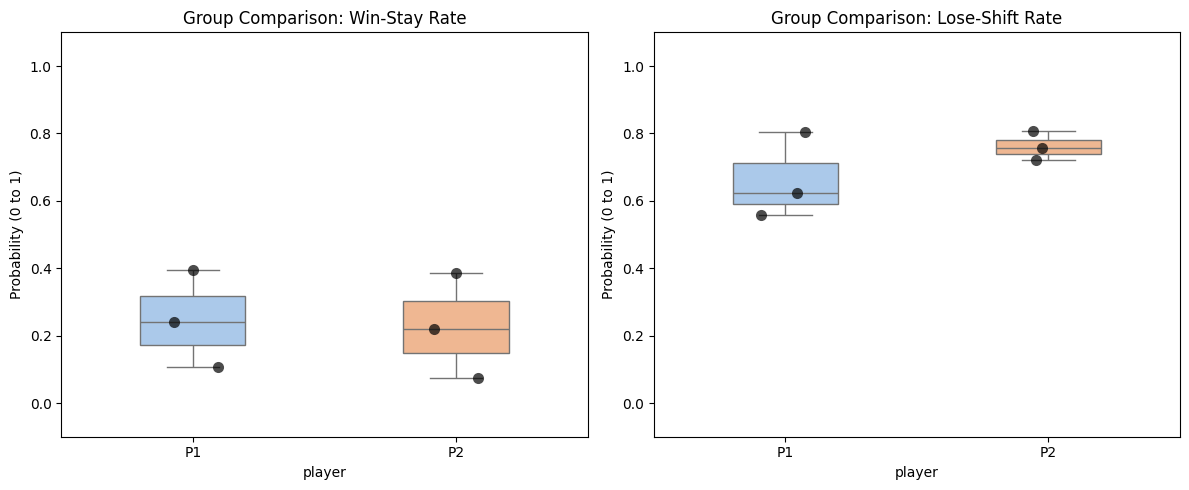

In [2]:
if csv_file.exists():
    # Set up a side-by-side plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Win-Stay Rate
    sns.boxplot(x='player', y='win_stay_rate', data=df, ax=ax1, width=0.4, palette='pastel')
    sns.stripplot(x='player', y='win_stay_rate', data=df, ax=ax1, color='black', alpha=0.7, size=8)
    ax1.set_title('Group Comparison: Win-Stay Rate')
    ax1.set_ylabel('Probability (0 to 1)')
    ax1.set_ylim(-0.1, 1.1)
    
    # Plot 2: Lose-Shift Rate
    sns.boxplot(x='player', y='lose_shift_rate', data=df, ax=ax2, width=0.4, palette='pastel')
    sns.stripplot(x='player', y='lose_shift_rate', data=df, ax=ax2, color='black', alpha=0.7, size=8)
    ax2.set_title('Group Comparison: Lose-Shift Rate')
    ax2.set_ylabel('Probability (0 to 1)')
    ax2.set_ylim(-0.1, 1.1)

    plt.tight_layout()
    plt.show()

In [3]:
if csv_file.exists():
    # Separate the groups
    p1_ws = df[df['player'] == 'P1']['win_stay_rate'].dropna()
    p2_ws = df[df['player'] == 'P2']['win_stay_rate'].dropna()
    
    # Run the independent T-test
    t_stat, p_val = stats.ttest_ind(p1_ws, p2_ws)
    
    print("=== Pipeline Verification ===")
    print(f"Hypothesis: Player 1 and Player 2 Win-Stay rates are different.")
    print(f"T-statistic: {t_stat:.3f}")
    print(f"P-value:     {p_val:.4f}")
    
    if p_val < 0.05:
        print("Conclusion: Significant Difference! (p < .05)")
    else:
        print("Conclusion: No Significant Difference. (p > .05)")

=== Pipeline Verification ===
Hypothesis: Player 1 and Player 2 Win-Stay rates are different.
T-statistic: 0.161
P-value:     0.8799
Conclusion: No Significant Difference. (p > .05)
